# 02_feature_extraction.ipynb

Objetivo:
- Cargar el dataset preprocesado (output del notebook de maria).
- Extraer embeddings (vectores) por imagen usando ResNet18 preentrenada (sin la última capa).
- Guardar los embeddings, etiquetas y nombres de clase en `backend/models/embeddings.joblib`.

¿Por qué?
- Los embeddings (p. ej. vectores de 512 dimensiones) representan cada imagen de forma compacta.
- Entrenar XGBoost sobre embeddings es mucho más rápido y efectivo que entrenar sobre píxeles crudos.


In [2]:
%pip install torch torchvision joblib tqdm --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Imports básicos y rutas
import os
import sys
import pickle
import numpy as np
import joblib
from tqdm import tqdm

# Asumimos que este notebook está en backend/notebooks/
# BASE_DIR -> carpeta backend
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "data", "desayuno_preprocessed")
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR (debe contener food101_desayuno_preprocessed.pkl y .npz):", DATA_DIR)
print("MODELS_DIR (salida embeddings):", MODELS_DIR)


BASE_DIR: c:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto7_ensemble_grupo2\backend\ML
DATA_DIR (debe contener food101_desayuno_preprocessed.pkl y .npz): c:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto7_ensemble_grupo2\backend\ML\data\desayuno_preprocessed
MODELS_DIR (salida embeddings): c:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto7_ensemble_grupo2\backend\ML\models


In [5]:
# Intentamos cargar usando el pkl que generó tu compañera.
PKL_PATH = os.path.join(DATA_DIR, "food101_desayuno_preprocessed.pkl")
if not os.path.exists(PKL_PATH):
    raise FileNotFoundError(f"No se encontró {PKL_PATH}. Asegúrate de ejecutar 00_download_data.ipynb y que la extracción fue correcta.")

# Cargar el pickle que contiene la lista de npz y class_names
with open(PKL_PATH, "rb") as f:
    info = pickle.load(f)

npz_files = info.get("npz_files")
class_names = info.get("class_names", None)

if not npz_files or len(npz_files) == 0:
    raise ValueError("No se encontraron npz en el .pkl (npz_files vacía). Revisa el .pkl.")

print("Num npz files in pkl:", len(npz_files))
print("Ejemplo npz file:", npz_files[0])
print("Num class names:", len(class_names) if class_names else "No class_names provistos")


Num npz files in pkl: 1049
Ejemplo npz file: c013_batch0050.npz
Num class names: 21


In [6]:
# Cargar todos los npz (esto puede consumir memoria; si tienes poco RAM, procesa por chunks)
X_parts = []
y_parts = []

for npz_rel in npz_files:
    npz_path = os.path.join(DATA_DIR, npz_rel)
    if not os.path.exists(npz_path):
        raise FileNotFoundError(f"No encontrado: {npz_path}")
    with np.load(npz_path) as npz:
        # Se espera que en cada npz haya arrays 'X' y 'y'
        X_parts.append(npz['X'])
        y_parts.append(npz['y'])

X = np.concatenate(X_parts, axis=0)
y = np.concatenate(y_parts, axis=0)

print("Loaded X shape:", X.shape)   # (N, H, W, C) normalmente
print("Loaded y shape:", y.shape)
print("Num unique classes in y:", np.unique(y).shape[0])


Loaded X shape: (20960, 48, 48, 3)
Loaded y shape: (20960,)
Num unique classes in y: 21


Shape global de X: (20960, 48, 48, 3)
Tipo de dato: float16
Valor mínimo: 0.0  | Valor máximo: 1.0
Nuevo rango: 0 255 | Tipo: uint8


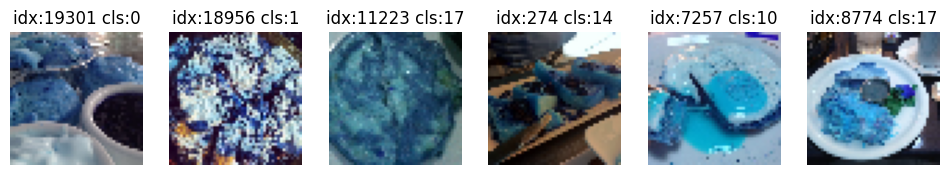

In [7]:
# ✅ Normalización de imágenes para visualización
# Las imágenes estaban en formato float16 (valores 0–1), por eso se veían negras.
# Multiplicamos por 255 y convertimos a uint8 para verlas correctamente.

print("Shape global de X:", X.shape)
print("Tipo de dato:", X.dtype)
print("Valor mínimo:", X.min(), " | Valor máximo:", X.max())

# 🔧 Corrige el rango de las imágenes de (0–1) → (0–255)
X_vis = (X * 255).astype("uint8")

# Verifica los valores corregidos
print("Nuevo rango:", X_vis.min(), X_vis.max(), "| Tipo:", X_vis.dtype)

# Visualiza algunas imágenes aleatorias
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 4))
for i in range(6):
    idx = np.random.randint(0, len(X_vis))
    plt.subplot(1, 6, i + 1)
    plt.imshow(X_vis[idx])
    plt.axis("off")
    plt.title(f"idx:{idx} cls:{y[idx]}")
plt.show()


# 🔧 Celda 7 — Preparar PyTorch, transforms y Dataset wrapper

Explicación:
- definimos un Dataset que toma tus arrays numpy (H,W,3) y aplica los transforms estándar de ImageNet que necesita ResNet.

In [8]:
# -----------------------
# Celda 7: Dataset + transforms
# -----------------------
import torch
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Dataset wrapper que transforma arrays numpy HWC -> PIL -> tensor preprocesado
class NumpyImageDataset(Dataset):
    def __init__(self, X_np, transform=None):
        """
        X_np: numpy array (N, H, W, C) with dtype uint8 or float in 0-255
        transform: torchvision transforms to apply
        """
        self.X = X_np
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img_np = self.X[idx]
        # Aseguramos que sea uint8 para PIL
        if img_np.dtype != 'uint8':
            img = Image.fromarray((img_np).astype('uint8'))
        else:
            img = Image.fromarray(img_np)
        if self.transform:
            img = self.transform(img)
        return img

# Transforms compatibles con ResNet (ImageNet)
transform = transforms.Compose([
    transforms.Resize((224,224)),       # ResNet espera 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# quick test: create small dataset to validate
ds_test = NumpyImageDataset(X_vis[:4], transform=transform)
sample = ds_test[0]
print("Sample tensor shape (C,H,W):", sample.shape)


Sample tensor shape (C,H,W): torch.Size([3, 224, 224])


# ⚙️ Celda 8 — Preparar extractor ResNet18 y comprobar salida
explicacion: 
- cargamos ResNet18 preentrenada y quitamos la capa final (fc) para usarla como extractor de features. Hacemos una pasada con un dummy para verificar shapes.

In [9]:
# -----------------------
# Celda 8: cargar ResNet18 preentrenada y preparar extractor
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Cargar ResNet18 preentrenada y quitar la capa fully-connected final
resnet = models.resnet18(pretrained=True)
modules = list(resnet.children())[:-1]   # todos los módulos excepto la última capa fc
feat_extractor = torch.nn.Sequential(*modules).to(device)
feat_extractor.eval()

# Verificar shape con dummy tensor
with torch.no_grad():
    dummy = torch.randn(1,3,224,224).to(device)
    out = feat_extractor(dummy)
    print("Extractor raw output shape (B, C, 1, 1):", out.shape)
    # lo que queremos luego es (B, C)


Using device: cuda


c:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto7_ensemble_grupo2\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto7_ensemble_grupo2\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Extractor raw output shape (B, C, 1, 1): torch.Size([1, 512, 1, 1])


# 🧪 Celda 9 — DataLoader y extracción de embeddings (el loop principal)

explicacion : 
- procesamos las imágenes en batches y apilamos las salidas como un array (N, D) donde D suele ser 512 para ResNet18. Ajusta BATCH_SIZE si tu memoria es limitada.

In [10]:
# -----------------------
# Celda 9 (GPU-aware) - extracción de embeddings en batches
# -----------------------
from tqdm import tqdm
import numpy as np
import torch
from torch.utils.data import DataLoader

# Ajustes (puedes bajar BATCH_SIZE si VRAM se agota)
BATCH_SIZE = 16       # GTX1650 (4GB) suele necesitar 16 o 32; baja si OOM
NUM_WORKERS = 0       # en Windows prueba 0 si hay problemas; en Linux 4 es ok

# Device ya debería ser 'cuda'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("torch.cuda.is_available():", torch.cuda.is_available())

# Si no quieres warnings, desactiva pin_memory si no hay GPU
pin_memory_flag = True if torch.cuda.is_available() else False

dataset = NumpyImageDataset(X_vis, transform=transform)  # usa X_vis (uint8) o X convertido
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=pin_memory_flag)

# Confirm GPU memory status (opcional)
try:
    import subprocess, shlex
    out = subprocess.run(shlex.split("nvidia-smi --query-gpu=memory.free,memory.total --format=csv,noheader,nounits"), capture_output=True, text=True)
    print("nvidia-smi (free,total MB):", out.stdout.strip())
except Exception:
    pass

emb_list = []
feat_extractor.eval()

with torch.no_grad():
    for batch in tqdm(loader, desc="Extracting embeddings"):
        batch = batch.to(device, non_blocking=pin_memory_flag)
        feats = feat_extractor(batch)                 # salida: B x C x 1 x 1
        feats = feats.view(feats.size(0), -1)         # B x C
        emb_list.append(feats.cpu().numpy())

embeddings = np.vstack(emb_list)
print("Embeddings final shape:", embeddings.shape)  # deberá ser (N, 512) para resnet18


Using device: cuda
torch.cuda.is_available(): True
nvidia-smi (free,total MB): 3775, 4096


Extracting embeddings: 100%|██████████| 1310/1310 [01:01<00:00, 21.15it/s]


Embeddings final shape: (20960, 512)


In [1]:
import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device 0:", torch.cuda.get_device_name(0))
    print("Total VRAM (MB):", torch.cuda.get_device_properties(0).total_memory // (1024*1024))


torch: 2.7.1+cu118
cuda available: True
Device 0: NVIDIA GeForce GTX 1650
Total VRAM (MB): 4095


# 💾 Celda 10 — Guardar embeddings + etiquetas + class_names 

explicacion : 
-  guardamos todo en un solo artefacto con joblib para que los notebooks posteriores usen el mismo archivo reproducible.

In [11]:
# Celda 10: guardar
import joblib, os
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)
out_path = os.path.join(MODELS_DIR, "embeddings.joblib")
joblib.dump({"embeddings": embeddings, "y": y, "class_names": class_names}, out_path, compress=3)
print("Saved embeddings to:", out_path)


Saved embeddings to: c:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto7_ensemble_grupo2\backend\ML\models\embeddings.joblib


# ✅ Celda 11 — Verificación / sanity check 

explicacion: 
- recargamos lo guardado y comprobamos shapes y algunos valores para estar seguros de que todo se guardó bien.

In [12]:
# Celda 11: comprobar lo guardado
data = joblib.load(out_path)
print("Loaded embeddings shape:", data["embeddings"].shape)
print("Loaded y shape:", data["y"].shape)
print("Sample embedding vector length:", data["embeddings"].shape[1])
print("Unique classes in y:", len(np.unique(data["y"])))


Loaded embeddings shape: (20960, 512)
Loaded y shape: (20960,)
Sample embedding vector length: 512
Unique classes in y: 21


# Celda 12: Notas y alternativas

- ✅ Resultado: ahora tienes `backend/models/embeddings.joblib` con:
    - embeddings: numpy array (N, D)  (D=512 para ResNet18)
    - y: etiquetas (N,)
    - class_names: lista de nombres por índice (si está disponible)

- Si tu equipo prefiere usar ResNet50 o EfficientNet, cambia `models.resnet18(pretrained=True)` por `models.resnet50(pretrained=True)` y recuerda que la dimensión del embedding será distinta (2048 para ResNet50).

- Si te quedas sin memoria GPU/CPU:
    - Reduce `BATCH_SIZE` (32 → 16 → 8).
    - Extrae embeddings en "chunks" (procesar uno o unos pocos .npz a la vez) en vez de cargar todo X en memoria.
    - Si usas Colab, activa GPU (Runtime -> Change runtime type -> GPU).

- Siguientes notebooks recomendados:
    - `03_train_xgboost.ipynb` — entrena XGBoost con StratifiedKFold usando `models/embeddings.joblib`.
    - `04_optuna_xgb.ipynb` — (opcional) optimiza hiperparámetros con Optuna.
    - `05_train_cnn.ipynb` — fine-tune ResNet end-to-end (usa X en lugar de embeddings).
